# CNN From Scrach

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [ ]:
# load data

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# reshape to (samples, channels, height, width)
x_train = x_train.reshape(-1,1,28,28)
x_test = x_test.reshape(-1,1,28,28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Defining Convolutional Layer

def conv_forward(image, filt, bias, stride=1):
    # extracting filter dimensions
    n_filters, n_c, f, _ = filt.shape
    # extracting image dimensions
    n_c, in_dim, _ = image.shape

    # calculating output dimension according to image and filter
    out_dim = int((in_dim - f)/stride) + 1

    # initializing output feature maps
    out = np.zeros((n_filters, out_dim, out_dim))


    # loop through each filter
    for curr_f in range(n_filters):
        curr_y = out_y = 0
        # this for moving filter vertically
        while curr_y + f <= in_dim:
            curr_x = out_x = 0
            # this for moving filter horizontally
            while curr_x + f <= in_dim:
                # the convolution operation
                out[curr_f, out_y, out_x] = np.sum(
                    filt[curr_f] * image[:, curr_y:curr_y+f, curr_x:curr_x+f]
                ) + bias[curr_f]
                # move filter position to right
                curr_x += stride
                out_x += 1
            # this for moving filter position to down
            curr_y += stride
            out_y += 1
    # returns extracted features
    return out


# this function will apply convolution filters to an input image to extract features
# it takes image, filt(kernel), bias (added after convolution) and stride (step size of filter movement) as input
# Extracting filter dimensions: n_filters is number of filters, n_c is channer (for RGB there are 3 and for our grayscale, there is only one), and f is the filter size.
# Extracting image dimensions: n_c is again channel, and in_dim is height and width
# applies multiple filters across the input image to extract important visual features
# Each filter slides across the image and computes element-wise multiplication followed by summation and bias addition
# This process generates feature maps that highlight patterns such as edges and curves, enabling the CNN to learn meaningful representations from the input



def conv_backward(dout, image, filt, stride=1):
    n_filters, n_c, f, _ = filt.shape
    _, in_dim, _ = image.shape

    dF = np.zeros_like(filt)
    dImage = np.zeros_like(image)
    dBias = np.zeros((n_filters,1))

    for curr_f in range(n_filters):
        curr_y = out_y = 0
        while curr_y + f <= in_dim:
            curr_x = out_x = 0
            while curr_x + f <= in_dim:
                dF[curr_f] += dout[curr_f, out_y, out_x] * \
                    image[:, curr_y:curr_y+f, curr_x:curr_x+f]

                dImage[:, curr_y:curr_y+f, curr_x:curr_x+f] += \
                    dout[curr_f, out_y, out_x] * filt[curr_f]

                curr_x += stride
                out_x += 1
            curr_y += stride
            out_y += 1

        dBias[curr_f] = np.sum(dout[curr_f])

    return dF, dBias, dImage

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_backward(dout, x):
    dx = dout.copy()
    dx[x <= 0] = 0
    return dx

In [ ]:
# function takes image, size of pooling window and
# stride of pooling window as input
def maxpool(image, size=2, stride=2):
    # getting dimension of the feature mape (we get it from conv_forward functoin)
    # channer, height, weight
    n_c, h_prev, w_prev = image.shape

    # calculates the heights and weights after max pooling
    h = int((h_prev - size)/stride) + 1
    w = int((w_prev - size)/stride) + 1

    # initializing output with zeroes
    downsampled = np.zeros((n_c, h, w))

    # looping through each feature map
    for i in range(n_c):
        curr_y = out_y = 0
        # while loop to move window veritcally
        while curr_y + size <= h_prev:
            curr_x = out_x = 0
            # while loop to move window horizontally
            while curr_x + size <= w_prev:
                # select maximum value from the window
                downsampled[i, out_y, out_x] = np.max(
                    image[i, curr_y:curr_y+size, curr_x:curr_x+size]
                )
                # move window to right
                curr_x += stride
                out_x += 1
            # move window to left
            curr_y += stride
            out_y += 1
    return downsampled

def maxpool_backward(dout, image, size=2, stride=2):
    n_c, h_prev, w_prev = image.shape
    dx = np.zeros_like(image)

    for i in range(n_c):
        curr_y = out_y = 0
        while curr_y + size <= h_prev:
            curr_x = out_x = 0
            while curr_x + size <= w_prev:
                window = image[i, curr_y:curr_y+size, curr_x:curr_x+size]
                max_val = np.max(window)

                for y in range(size):
                    for x in range(size):
                        if window[y, x] == max_val:
                            dx[i, curr_y+y, curr_x+x] = dout[i, out_y, out_x]

                curr_x += stride
                out_x += 1
            curr_y += stride
            out_y += 1

    return dx



In [ ]:
# softmax converts raw output scores into probabilities
# we subtract by np.max(x) to prevent numerical overflow when exponent value become very large
# cross_entropy measures how wrong the prediction is
# if predicted probability is too far from true probability, it will assing bigger loss
# otherewise, it will assign a smaller loss


def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def cross_entropy(pred, label):
    return -np.log(pred[label])

def softmax_crossentropy_backward(probs, label):
    grad = probs.copy()
    grad[label] -= 1
    return grad

In [ ]:
# Fully Connected Layer

def dense(x, W, b):
    return np.dot(W, x) + b


def dense_backward(dout, x, W):
    dW = np.dot(dout, x.T)
    db = dout
    dx = np.dot(W.T, dout)
    return dW, db, dx

In [ ]:
np.random.seed(0)


# 8 filters of 3x3 size
# dividing by 9 keeps values small and maintains stable learning
filt = np.random.randn(8,1,3,3) / 9
# to shift activation values
bias = np.zeros((8,1))

# 10 weights for 10 output classes
W = np.random.randn(10, 1352) * 0.01
# 10 biase
b = np.zeros((10,1))

In [ ]:
lr = 0.01

for i in range(100):   # train on 100 images
    img = x_train[i]
    label = y_train[i]

    # -------- Forward --------
    conv = conv_forward(img, filt, bias)
    relu_out = relu(conv)
    pool = maxpool(relu_out)
    fc_input = pool.flatten().reshape(-1,1)
    out = dense(fc_input, W, b)
    probs = softmax(out)

    loss = cross_entropy(probs, label)

    # -------- Backward --------
    dout = softmax_crossentropy_backward(probs, label)

    dW, db, d_fc = dense_backward(dout, fc_input, W)

    d_pool = d_fc.reshape(pool.shape)

    d_relu = maxpool_backward(d_pool, relu_out)

    d_conv = relu_backward(d_relu, conv)

    dF, dBias, dImage = conv_backward(d_conv, img, filt)

    # -------- Update --------
    W -= lr * dW
    b -= lr * db
    filt -= lr * dF
    bias -= lr * dBias

    if i % 10 == 0:
        print("Loss:", loss)

/tmp/ipython-input-1511/3003552070.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  out[curr_f, out_y, out_x] = np.sum(


Loss: [2.27939796]
Loss: [2.17035356]
Loss: [2.32689133]
Loss: [2.02405564]
Loss: [2.14270771]
Loss: [1.83914763]
Loss: [2.15076088]
Loss: [2.23289936]
Loss: [2.7461253]
Loss: [1.46318599]


# YOLO

In [ ]:
# Check GPU
!nvidia-smi

# Install YOLOv8
!pip install ultralytics

# Clone YOLOv5
!git clone https://github.com/ultralytics/yolov5

Wed Feb 25 09:46:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             32W /   70W |    1769MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from ultralytics import YOLO
from ultralytics.utils.downloads import download

# YOLO V8

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
from ultralytics import YOLO

# taking weights and bias of YOLO v8
model_v8 = YOLO("yolov8s.pt")

# this is finetuning for our own dataset
model_v8.train(
    data="/content/drive/MyDrive/brain-tumor/brain-tumor.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    name="yolov8_brain"
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/brain-tumor/brain-tumor.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_brain, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fddbc81a180>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:

model_v8.val()

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 150.9±70.1 MB/s, size: 3.4 KB)
val: Scanning /content/yolov5/brain-tumor/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 52.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.6it/s 5.4s
                   all        223        241      0.432      0.844      0.496      0.369
              negative        142        154      0.557      0.825      0.617       0.46
              positive         81         87      0.307      0.862      0.376      0.278
Speed: 3.9ms preprocess, 9.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/yolov5/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fdfacec3a70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
model_v8.predict(source="/content/drive/MyDrive/brain-tumor/images/val",save=True)


image 1/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (1).jpg: 640x640 1 negative, 1 positive, 17.5ms
image 2/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (10).jpg: 640x640 1 negative, 17.4ms
image 3/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (100).jpg: 640x640 1 negative, 2 positives, 32.8ms
image 4/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (101).jpg: 640x640 1 positive, 33.7ms
image 5/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (102).jpg: 640x640 1 positive, 28.5ms
image 6/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (103).jpg: 640x640 1 positive, 28.2ms
image 7/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (104).jpg: 640x640 1 negative, 1 positive, 24.7ms
image 8/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (105).jpg: 640x640 1 negative, 1 positive, 36.2ms
image 9/223 /content/drive/MyDrive/brain-tumor/images/val/val_1 (106).jpg: 640x640 1 negative, 1 positive, 52.5ms
image 10/223 /content/d

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'negative', 1: 'positive'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
      

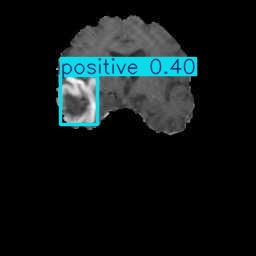

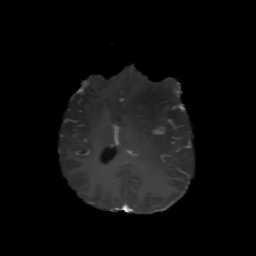

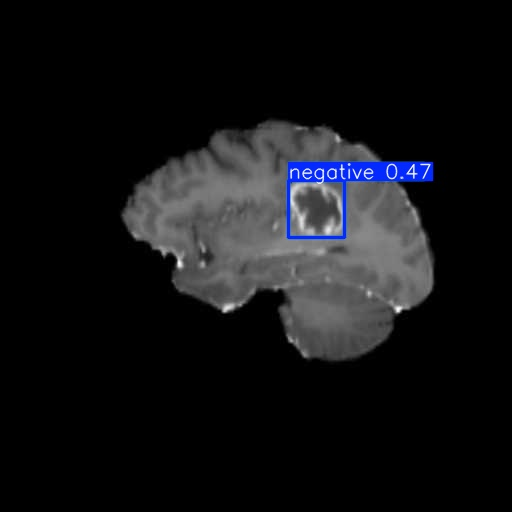

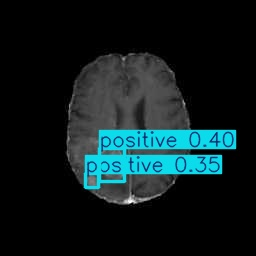

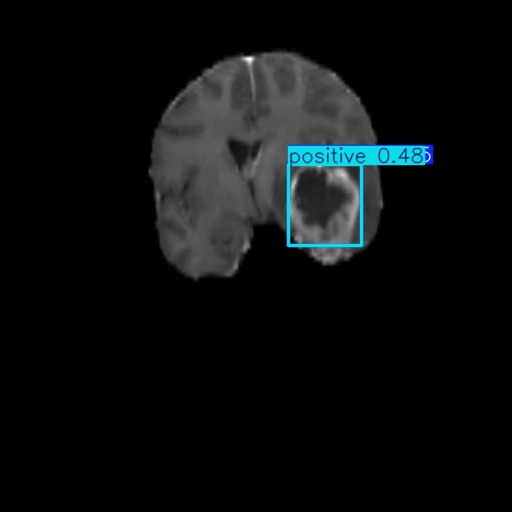

In [ ]:
from IPython.display import Image, display
import os

folder = "/content/runs/detect/predict"

for img in os.listdir(folder)[:5]:
    display(Image(os.path.join(folder, img)))

# YOLO V5

In [ ]:
!cp -r /content/drive/MyDrive/brain-tumor /content/yolov5/

In [ ]:
%cd /content/yolov5

!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 10 \
  --data brain-tumor/brain-tumor.yaml \
  --weights yolov5s.pt \
  --name yolov5_brain_fixed \
  --exist-ok \
  --workers 2 \
  --cache

/content/yolov5
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-02-25 09:51:33.282085: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772013093.512869   11642 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772013093.580042   11642 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772013094.031094   11642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772013094.031137   11642 computation_placer.cc:177] computation placer a

In [ ]:
!ls runs/train/yolov5_brain_fixed/weights/

best.pt  last.pt


In [ ]:
!python val.py \
  --weights runs/train/yolov5_brain_fixed/weights/best.pt \
  --data brain-tumor/brain-tumor.yaml \
  --img 640

val: data=brain-tumor/brain-tumor.yaml, weights=['runs/train/yolov5_brain_fixed/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command

In [ ]:
!python detect.py \
  --weights runs/train/yolov5_brain_fixed/weights/best.pt \
  --source brain-tumor/images/val \
  --conf 0.25

detect: weights=['runs/train/yolov5_brain_fixed/weights/best.pt'], source=brain-tumor/images/val, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_versi

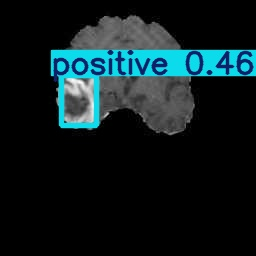

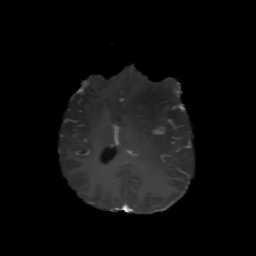

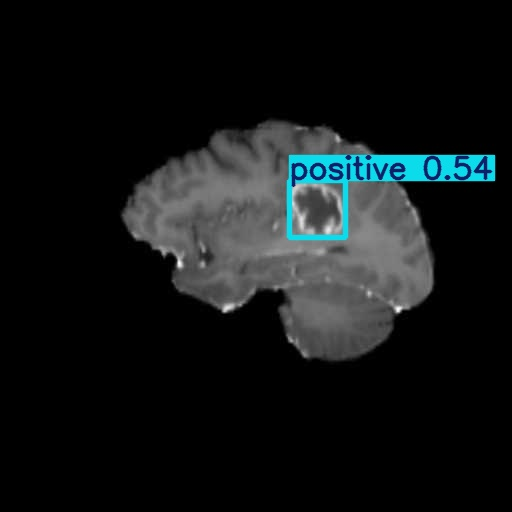

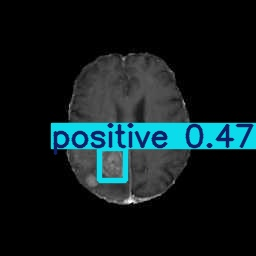

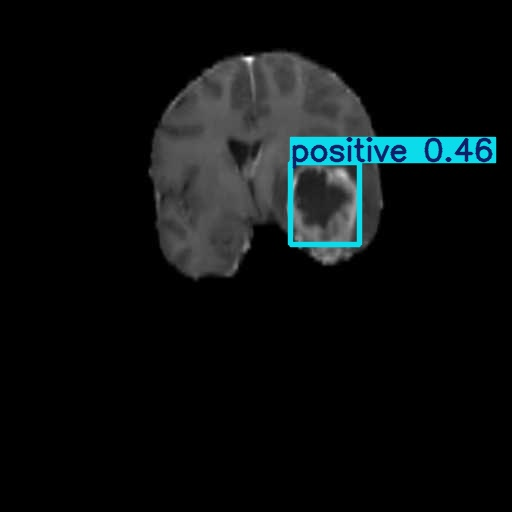

In [ ]:
from IPython.display import Image, display
import os

folder = "runs/detect/exp"

for img in os.listdir(folder)[:5]:
    display(Image(os.path.join(folder, img)))

# Comparision YOLO v5 VS YOLO v8

**Technical Interpretation**

YOLOv5:

- Higher Recall → detects more tumors
- Better mAP50 → better general detection
- Lighter model

YOLOv8:

- Better mAP50-95 → better bounding box precision
- More modern architecture
- Slightly heavier

# Ensemble Learning

In [ ]:
!pip install ensemble-boxes

In [ ]:
from ultralytics import YOLO
import torch

# Load YOLOv8
model_v8 = YOLO("runs/detect/yolov8_brain/weights/best.pt")

# Load YOLOv5
model_v5 = torch.hub.load('ultralytics/yolov5',
                          'custom',
                          path='runs/train/yolov5_brain_fixed/weights/best.pt',
                          force_reload=True)

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
requirements: Ultralytics requirement ['urllib3>=2.6.0 ; python_version > "3.8"'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/usr/bin/python3" "urllib3>=2.6.0 ; python_version > "3.8""  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
error: Failed to parse: `urllib3>=2.6.0 ; python_version > 3.8`
  Caused by: Expect

YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [ ]:
image_path = "/content/drive/MyDrive/brain-tumor/images/val/val_1 (1).jpg"

# YOLOv8 prediction
results_v8 = model_v8(image_path)[0]

# YOLOv5 prediction
results_v5 = model_v5(image_path)


image 1/1 /content/drive/MyDrive/brain-tumor/images/val/val_1 (1).jpg: 640x640 1 negative, 1 positive, 16.1ms
Speed: 2.7ms preprocess, 16.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
import numpy as np
import cv2

image = cv2.imread(image_path)
h, w, _ = image.shape
def prepare_boxes(results, is_v8=True):
    boxes = []
    scores = []
    labels = []
    if is_v8:
        for box in results.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())

            boxes.append([x1/w, y1/h, x2/w, y2/h])
            scores.append(conf)
            labels.append(cls)
    else:
        for *xyxy, conf, cls in results.xyxy[0]:
            x1, y1, x2, y2 = [x.item() for x in xyxy]
            boxes.append([x1/w, y1/h, x2/w, y2/h])
            scores.append(conf.item())
            labels.append(int(cls.item()))

    return boxes, scores, labels

boxes_v8, scores_v8, labels_v8 = prepare_boxes(results_v8, True)
boxes_v5, scores_v5, labels_v5 = prepare_boxes(results_v5, False)

In [ ]:
from ensemble_boxes import weighted_boxes_fusion

boxes_list = [boxes_v8, boxes_v5]
scores_list = [scores_v8, scores_v5]
labels_list = [labels_v8, labels_v5]

boxes, scores, labels = weighted_boxes_fusion(
    boxes_list,
    scores_list,
    labels_list,
    iou_thr=0.5,
    skip_box_thr=0.3
)

# Visualize image side by side

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_boxes(image_path, boxes, scores, labels, color=(0,255,0), title="Model"):
    image = cv2.imread(image_path)
    h, w, _ = image.shape

    for box, score, label in zip(boxes, scores, labels):
        x1 = int(box[0] * w)
        y1 = int(box[1] * h)
        x2 = int(box[2] * w)
        y2 = int(box[3] * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, f"{label}: {score:.2f}",
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, color, 2)

    return image

In [ ]:
# YOLOv8
boxes_v8, scores_v8, labels_v8 = prepare_boxes(results_v8, True)

# YOLOv5
boxes_v5, scores_v5, labels_v5 = prepare_boxes(results_v5, False)

# Ensemble (already computed using WBF)
boxes_ens, scores_ens, labels_ens = boxes, scores, labels

In [ ]:
img_v8 = draw_boxes(image_path, boxes_v8, scores_v8, labels_v8, (0,255,0), "YOLOv8")
img_v5 = draw_boxes(image_path, boxes_v5, scores_v5, labels_v5, (255,0,0), "YOLOv5")
img_ens = draw_boxes(image_path, boxes_ens, scores_ens, labels_ens, (0,0,255), "Ensemble")

In [ ]:
print(type(img_v5), img_v5.shape if img_v5 is not None else "None")
print(type(img_v8), img_v8.shape if img_v8 is not None else "None")
print(type(img_ens), img_ens.shape if img_ens is not None else "None")

<class 'numpy.ndarray'> (512, 512, 3)
<class 'numpy.ndarray'> (512, 512, 3)
<class 'numpy.ndarray'> (512, 512, 3)


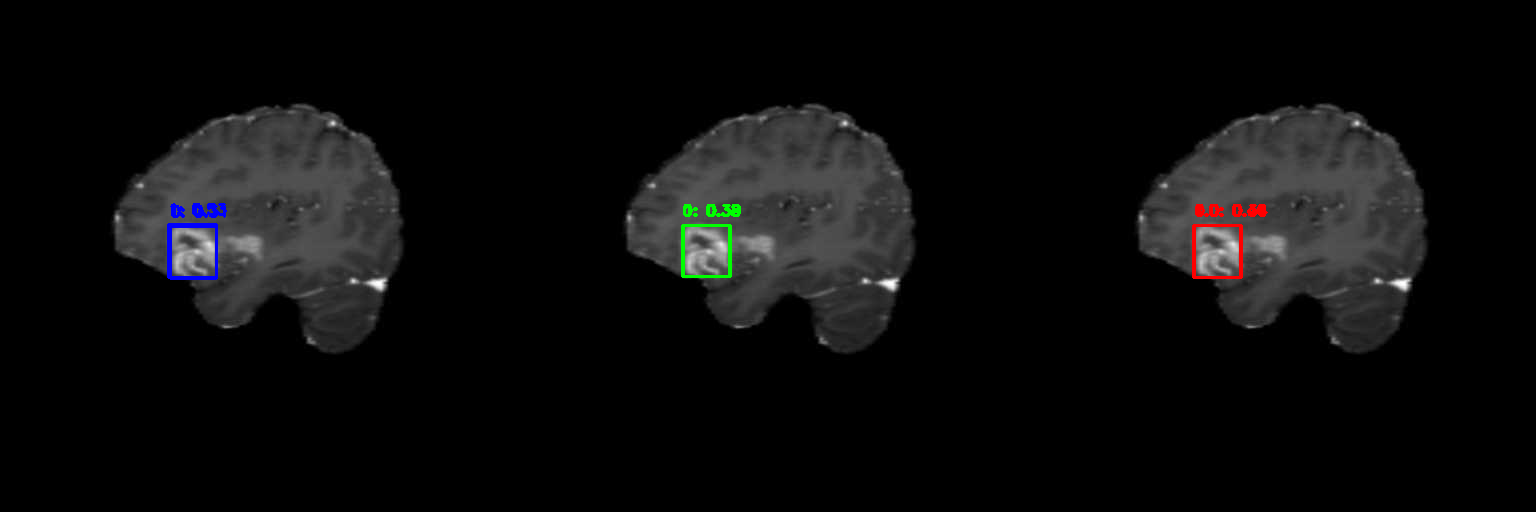

In [ ]:
from google.colab.patches import cv2_imshow
import numpy as np

combined = np.concatenate([img_v5, img_v8, img_ens], axis=1)

cv2_imshow(combined)

**Technical Interpretation**

YOLOv5:

- Higher Recall → detects more tumors
- Better mAP50 → better general detection
- Lighter model

YOLOv8:

- Better mAP50-95 → better bounding box precision
- More modern architecture
- Slightly heavier